# Internet connectivity

Mean fixed-broadband download speed per 0.5° grid cell, from **[Ookla Speedtest Open Data](https://github.com/teamookla/ookla-open-data)** — quarterly global tile datasets published under CC BY-NC-SA 4.0. Each source row is a Zoom-16 Web-Mercator tile (~600 m near the equator) carrying the average speed of every Speedtest run inside it during the quarter, alongside the number of tests. We aggregate those tiles onto the atlas grid as a **tests-weighted mean of `log10(download Mbps)`**, so a cell where 5 000 tests average 200 Mbps outweighs one where 3 tests happened to hit a rural gigabit line.

Higher = faster median connection = better. Cells with zero Speedtest coverage stay `NaN` — the atlas `weighted_score` renormalizes weights per-cell, so unknown internet neither drags nor lifts a location. Ocean is masked via `is_land` from `grid.nc` for consistency.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

from common import RAW_DIR, download, load_grid, plot_map, save_variable

VARIABLE = 'internet_connectivity'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

# Latest quarter Ookla has published as of writing. The file for a quarter
# usually appears ~4-6 weeks after the quarter ends, so bump these once a new
# release lands. `SERVICE = 'fixed'` for home broadband; switch to `'mobile'`
# for cellular.
YEAR, QUARTER = 2026, 2
SERVICE = 'fixed'
QUARTER_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}[QUARTER]
STAMP = f'{YEAR}-{QUARTER_MONTH:02d}-01'

## 1. Fetch raw data

One parquet per quarter, hosted on the public `ookla-open-data` S3 bucket — a few hundred MB for fixed broadband, a bit smaller for mobile. Cached under `variable_raw`; the download only runs once.

In [2]:
OOKLA_BASE = 'https://ookla-open-data.s3.amazonaws.com/parquet/performance'
filename = f'{STAMP}_performance_{SERVICE}_tiles.parquet'
parquet_path = variable_raw / filename

if not parquet_path.exists():
    url = f'{OOKLA_BASE}/type={SERVICE}/year={YEAR}/quarter={QUARTER}/{filename}'
    print(f'downloading {url}')
    await download(url, parquet_path)

print(f'{parquet_path.name}: {parquet_path.stat().st_size / 1024**2:.0f} MB')

2026-04-01_performance_fixed_tiles.parquet: 338 MB


## 2. Load and geolocate tiles

Only three columns are needed per row — the `quadkey` locates the tile, `avg_d_kbps` is the value, `tests` is its weight. Skipping the WKT `tile` polygon and the mobile-only latency/upload fields keeps the DataFrame small (a few hundred MB → tens of MB).

A Zoom-16 quadkey is a 16-character string of `0..3` digits: each digit encodes one bit of `tile_x` (from the digit's low bit) and one of `tile_y` (from the high bit), most-significant first. Parsing all quadkeys as a `(N, 16)` byte matrix and shifting bit-by-bit lets numpy do the whole conversion in ~16 vectorised passes — no per-row Python loop.

Tile centres go through the standard inverse Web-Mercator: `lon` is linear in `tile_x`, `lat` uses `atan(sinh(π · (1 − 2 y_norm)))`. The Mercator projection caps at ±85.05°, so any cells north of that in the atlas grid are simply unreachable from this dataset.

In [3]:
df = pd.read_parquet(parquet_path, columns=['quadkey', 'avg_d_kbps', 'tests'])
print(f'{len(df):,} tiles loaded')

ZOOM = 16
N_TILES = 1 << ZOOM  # 65 536 tiles per axis at zoom 16

# (N, 16) uint8 matrix of digits 0..3, one row per quadkey.
codes = np.frombuffer(''.join(df['quadkey'].values).encode('ascii'), dtype=np.uint8)
codes = codes.reshape(-1, ZOOM) - ord('0')

tile_x = np.zeros(len(df), dtype=np.uint32)
tile_y = np.zeros(len(df), dtype=np.uint32)
for j in range(ZOOM):
    bit = np.uint32(1 << (ZOOM - 1 - j))
    tile_x |= (codes[:, j] & 1).astype(np.uint32) * bit
    tile_y |= ((codes[:, j] >> 1) & 1).astype(np.uint32) * bit

lon = (tile_x + 0.5) / N_TILES * 360.0 - 180.0
y_norm = (tile_y + 0.5) / N_TILES
lat = np.degrees(np.arctan(np.sinh(np.pi * (1 - 2 * y_norm))))
print(f'lat range: {lat.min():.2f}..{lat.max():.2f}; lon range: {lon.min():.2f}..{lon.max():.2f}')

6,435,919 tiles loaded
lat range: -78.47..82.50; lon range: -180.00..179.99


## 3. Aggregate tiles onto the atlas grid

For each tile: figure out which atlas cell its centre falls into, then contribute `tests · log10(Mbps)` to the numerator and `tests` to the denominator of that cell. The final layer is `numerator / denominator` — a tests-weighted geometric mean of download speed. `np.bincount` does both accumulations in one vectorised pass over the whole tile table.

Working in `log10(Mbps)` matters: raw Mbps spans ~4 orders of magnitude between rural DSL (~1 Mbps) and fibre (~1 Gbps), so an arithmetic mean lets a handful of gigabit tiles dominate a cell that's otherwise mostly 20 Mbps. The log-mean corresponds to the *median-order-of-magnitude* speed a household there is likely to see.

In [4]:
grid = load_grid()
NLAT, NLON = grid.lat.size, grid.lon.size
RES = float(grid.lat.diff('lat').mean())
LAT_MIN = float(grid.lat.min()) - RES / 2
LON_MIN = float(grid.lon.min()) - RES / 2

col_idx = np.floor((lon - LON_MIN) / RES).astype(np.int64)
row_idx = np.floor((lat - LAT_MIN) / RES).astype(np.int64)

mbps = df['avg_d_kbps'].to_numpy(dtype=np.float64) / 1000.0
tests = df['tests'].to_numpy(dtype=np.float64)

# Guard: Ookla filters out zero-test tiles, but drop anything non-positive to
# keep log10 defined. Also clip to the atlas extent (Mercator overshoots on the
# poles by a tiny margin after the +0.5 tile-centre offset).
valid = (
    (tests > 0) & (mbps > 0)
    & (row_idx >= 0) & (row_idx < NLAT)
    & (col_idx >= 0) & (col_idx < NLON)
)
log_mbps = np.log10(mbps[valid])
w = tests[valid]
cell = row_idx[valid] * NLON + col_idx[valid]

numerator = np.bincount(cell, weights=w * log_mbps, minlength=NLAT * NLON)
denominator = np.bincount(cell, weights=w, minlength=NLAT * NLON)

with np.errstate(invalid='ignore', divide='ignore'):
    log_mean = np.where(denominator > 0, numerator / denominator, np.nan)

values = xr.DataArray(
    log_mean.reshape(NLAT, NLON).astype('float32'),
    coords={'lat': grid.lat, 'lon': grid.lon},
    dims=('lat', 'lon'),
    name=VARIABLE,
).where(grid.is_land == 1)
values.attrs['units'] = 'log₁₀(Mbps)'
values.attrs['source'] = f'Ookla Speedtest Open Data ({SERVICE} tiles, {STAMP})'
values.attrs['aggregation'] = 'tests-weighted mean of log10(avg_d_kbps / 1000) per 0.5° cell'

coverage = float((denominator > 0).sum()) / (NLAT * NLON)
print(f'{coverage * 100:.1f}% of cells have Speedtest coverage')
print(f'log10(Mbps) range: {float(values.min()):.2f} .. {float(values.max()):.2f} '
      f'(i.e. {10 ** float(values.min()):.2f} .. {10 ** float(values.max()):.0f} Mbps)')

12.4% of cells have Speedtest coverage
log10(Mbps) range: -2.40 .. 3.22 (i.e. 0.00 .. 1664 Mbps)


## 4. Plot

<Axes: title={'center': 'internet_connectivity'}, xlabel='longitude', ylabel='latitude'>

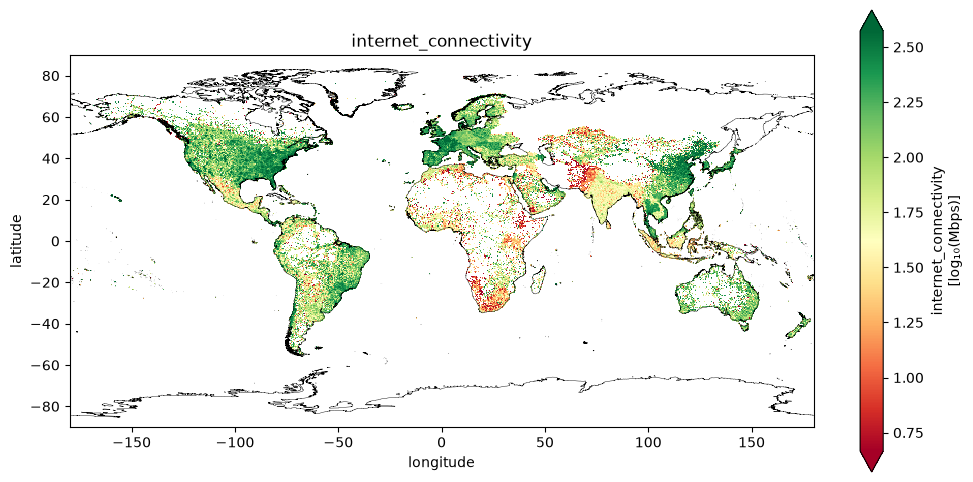

In [5]:
plot_map(values, robust=True)

## 5. Save

In [6]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/internet_connectivity.nc
